<a href="https://colab.research.google.com/github/meirBal/meir/blob/main/207116872_Ex1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cars 2025: A Comprehensive Exploratory Data Analysis

# Setup and Library Imports (Environment Preparation)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import kagglehub
import os

# Set display style for plots
sns.set_theme(style="whitegrid")

# Helper Libraries

In [ ]:
## Dictionary of Key Commands Used in this Notebook

---

This section outlines some of the more specific or advanced commands and techniques utilized throughout this notebook, providing a quick reference for understanding the methodologies applied.

- **`!chmod 600 ~/.kaggle/kaggle.json`**: Changes file permissions of 'kaggle.json' to read/write for the owner only.
- **`!cp kaggle.json ~/.kaggle/`**: Copies the 'kaggle.json' file to the '.kaggle' directory.
- **`!kaggle datasets download ...`**: Downloads a dataset from Kaggle using the Kaggle CLI.
- **`!mkdir -p ~/.kaggle`**: Creates a directory named '.kaggle' in the user's home directory if it doesn't already exist.
- **`.astype('Int64')`**: Casts a pandas Series to an integer type that can handle NaN values.
- **`.str.contains('Hybrid', na=False)`**: Checks if a string column contains a substring, treating NaNs as False.
- **`.str.extract(r'(\d+)', expand=False)`**: Extracts numerical patterns from a string column using regular expressions.
- **`.str.replace('$', '', regex=False)`**: Replaces occurrences of a substring in a string column.
- **`.value_counts().nlargest(10).index.tolist()`**: Gets the index of the top 10 most frequent values in a Series as a list.
- **`~is_electric & ~is_hybrid`**: Performs logical NOT and AND operations on boolean Series to select specific rows.
- **`df.drop_duplicates(inplace=True)`**: Removes duplicate rows from the DataFrame, modifying it in place.
- **`df.groupby(...)['Performance_cleaned'].median()`**: Calculates the median of a column grouped by another column (used for group-based imputation).
- **`df.loc[...] `**: Accesses a group of rows and columns by label(s) or a boolean array.
- **`df.loc[:, 'Performance_cleaned'] = ...`**: Assigns values to a specific column using the `.loc` accessor.
- **`df.dropna(subset=[...]).copy()`**: Removes rows with NaN values in specified columns and returns a copy.
- **`df.nunique().values`**: Returns an array of the number of unique values for each column in the DataFrame.
- **`df_clean.select_dtypes(include=np.number)`**: Selects columns with numerical data types from the DataFrame.
- **`df['Simplified_Engines'].apply(simplify_engine_name)`**: Applies a custom function (`simplify_engine_name`) to a DataFrame column.
- **`np.nan`**: Represents a missing numerical value (Not a Number).
- **`np.median(np.abs(df_clean[col] - median))`**: Calculates the Median Absolute Deviation (MAD) of a Series.
- **`pd.cut(...)`**: Bins numerical data into discrete intervals.
- **`pd.notna(...)`**: Checks if a value is not NaN (Not a Number).
- **`pd.to_numeric(...)`**: Converts arguments to a numeric type, coercing errors to NaN.
- **`plt.yscale('log')`**: Sets a logarithmic scale on the y-axis of the current plot.
- **`pd.crosstab(...)`**: Computes a frequency table of two (or more) factors.
- **`scipy.stats.chi2_contingency(...)`**: Performs a chi-square test of independence on a contingency table.
- **`sns.heatmap(..., annot=True, cmap='coolwarm')`**: Plots a heatmap of a matrix with annotations and a 'coolwarm' color map.
- **`sns.pairplot(...)`**: Plots pairwise relationships between variables in a DataFrame.
- **`sns.regplot(...)`**: Plots data and a linear regression model fit with a regression line.
- **`stats.zscore(...)`**: Calculates the Z-score for each value in a Series, indicating how many standard deviations it is from the mean.
- **`uploaded = files.upload()`**: Opens a file browser to upload files from the local system to the Colab environment.

## Dictionary of Commands Used in this Notebook
---
- **`!chmod 600 ~/.kaggle/kaggle.json`**: Changes file permissions of 'kaggle.json' to read/write for the owner only.
- **`!cp kaggle.json ~/.kaggle/`**: Copies the 'kaggle.json' file to the '.kaggle' directory.
- **`!kaggle datasets download ...`**: Downloads a dataset from Kaggle using the Kaggle CLI.
- **`!mkdir -p ~/.kaggle`**: Creates a directory named '.kaggle' in the user's home directory if it doesn't already exist.
- **`!pip install kaggle`**: Installs the 'kaggle' Python package using pip.
- **`!unzip ...`**: Extracts files from a zip archive.
- **`.apply(lambda row: ..., axis=1)`**: Applies a function along the DataFrame's rows.
- **`.astype('Int64')`**: Casts a pandas Series to an integer type that can handle NaN values.
- **`.quantile(0.25)`**: Calculates the 25th percentile (Q1) of a Series.
- **`.str.contains('Hybrid', na=False)`**: Checks if a string column contains a substring, treating NaNs as False.
- **`.str.extrac

* df.head(n) - view n first rows
* df.tail(n) - view n last rows
* df.info() - check data info
* .loc[...] - to select data using row and column labels (names).
* .iloc[...] - to select data using integer positions
* df.sort_values(...) - sorts values
* df.isnull() - to check for missing data
* df[col_name].value_counts() - return the number of times each unique value appears in a column
* df.groupby(...) - for group analysis
* df[col_name].unique() - get the unique values of a column



# Part 1 - Dataset Selection

> Source of Data: The data was downloaded from the Kaggle platform and contains detailed information about cars for the year 2025 (Cars Datasets 2025). 2. Purpose of Collection: This information is intended to facilitate project building and market research in the automotive industry, covering aspects such as acceleration performance, speed, horsepower, market prices (in USD), and propulsion types (petrol, hybrid, electric, diesel). 3. Meeting Requirements: The dataset meets the assignment's requirements – it is tabular, contains over 1000 rows, more than 10 columns (companies, models, price, fuel type, seats, etc.), and includes both numerical and categorical variables.

## Dataset Overview for Data Analysts

This section provides essential details about the 'Cars Datasets 2025' dataset, crucial for any data analyst working with this file.

**1. Dataset Name:** Cars Datasets 2025

**2. Source:** Kaggle Platform
   *   **Kaggle Dataset ID:** `abdulmalik1518/cars-datasets-2025`
   *   **Direct URL:** [https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025](https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025)
   *   **Uploader:** abdulmalik1518
   *   **License:** Apache-2.0

**3. Date Accessed:** This dataset was downloaded and integrated into the notebook for analysis on [Insert Current Date/Approximate Access Date if known, e.g., April 2026 based on Kaggle logs].

**4. Purpose of Collection:** This dataset was collected to facilitate project building and market research within the automotive industry. It provides detailed information on various car models for the year 2025, enabling analysis of market trends, performance benchmarks, and competitive landscapes.

**5. Key Data Characteristics:**
   *   **Structure:** Tabular data.
   *   **Size:** Contains an initial 1218 entries (rows) and 11 columns, with cleaned data resulting in 1213 entries and additional derived columns.
   *   **Variables:** The dataset includes a mix of numerical and categorical variables:
        *   **Numerical (Cleaned):** `HorsePower_cleaned`, `Total Speed_cleaned`, `Cars Prices_cleaned`, `Torque_cleaned`, `CC_Capacity_cleaned`, `Battery_Capacity_cleaned`, `Performance_cleaned`.
        *   **Categorical:** `Company Names`, `Cars Names`, `Fuel Types`, `Seats`, `Engine_Category`.
   *   **Content Focus:** Covers aspects such as acceleration performance, top speed, horsepower, market prices (in USD), and propulsion types (petrol, hybrid, electric, diesel).

**6. Data Granularity:** Each row typically represents a specific car model with its detailed specifications.

> KAGGLE

In [ ]:
# Install the Kaggle library
!pip install kaggle

In [ ]:
# Upload the Kaggle API key to your notebook
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle (1).json


In [ ]:
# Place the API key where the Kaggle library can recognize it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download abdulmalik1518/cars-datasets-2025
!unzip cars-datasets-2025.zip

Dataset URL: https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025
License(s): apache-2.0
cars-datasets-2025.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  cars-datasets-2025.zip
replace Cars Datasets 2025.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Cars Datasets 2025.csv  


In [ ]:
import pandas as pd

data = pd.read_csv('./Cars Datasets 2025.csv', encoding='latin1')
df = data

## Part 2 - Initial Data Inspection and Cleansing

Our first step is to gain a foundational understanding of the dataset's structure and contents. This involves inspecting the data types, identifying missing values, and detecting any duplicate entries. Addressing these basic issues early ensures that our subsequent analysis is based on a robust and reliable dataset. We want to quickly see the general health of our data.

In [ ]:
# Display basic information about the DataFrame, including data types and non-null counts.
df.info()

# Check for and remove duplicate rows to ensure each entry is unique.
print(f"\nNumber of duplicate rows in df before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows in df after removal: {df.duplicated().sum()}")

# Display a summary of missing values for all columns, showing count and percentage.
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing_data, 'Percent (%)': missing_percent})
print("\n--- Missing Values Initial Check ---")
display(missing_df[missing_df['Missing'] > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB

Number of duplicate rows in df before removal: 4
Number of duplicate rows in df after removal: 0

--- Missing Values Initial Check ---

,Missing,Percent (%)
CC/Battery Capacity,3,0.247117
Performance(0 - 100 )KM/H,6,0.494234
Torque,1,0.082372


### Cardinality Check and Unique Value Analysis

Beyond duplicates, understanding the cardinality of each column—the number of unique values it contains—is crucial. Low cardinality columns (especially those with just one unique value) might be constant and thus uninformative for analysis, or indicate potential issues if they should have more variance. High cardinality columns (many unique values) can point to identifier-like features or require specific handling for categorical analysis.


In [ ]:
import pandas as pd
import os

# Ensure df is defined for this cell's execution, in case previous cells were not run.
# This code snippet is a safeguard and assumes the data file 'Cars Datasets 2025.csv' is available.
try:
    # Attempt to use existing df if it's already defined
    df.head()
except NameError:
    # If df is not defined, first check if the file exists
    file_path = './Cars Datasets 2025.csv'
    if not os.path.exists(file_path):
        print(f"File not found: {file_path}. Attempting to re-download and unzip.")
        # Re-run Kaggle download and unzip commands. This assumes Kaggle API is already configured.
        # Adding -q for quiet output and -o for overwrite (if zip exists) for unzip.
        !kaggle datasets download abdulmalik1518/cars-datasets-2025 -q
        !unzip -o cars-datasets-2025.zip -d .
        # Remove the zip file after extraction to keep the directory clean
        if os.path.exists('cars-datasets-2025.zip'):
            os.remove('cars-datasets-2025.zip')

    # Now try to load the data from the (now hopefully present) file
    data = pd.read_csv(file_path, encoding='latin1')
    df = data

# Check cardinality for all columns in the current DataFrame.
print("--- Cardinality of each column in df ---")
cardinality_df = pd.DataFrame({'Column': df.columns, 'Unique Values': df.nunique().values})
display(cardinality_df.sort_values(by='Unique Values', ascending=False))

# Identify columns with very low cardinality (e.g., only one unique value).
single_value_cols = cardinality_df[cardinality_df['Unique Values'] == 1]['Column'].tolist()

if single_value_cols:
    print(f"\n--- Columns with only one unique value (potentially uninformative): {single_value_cols} ---\n")
    for col in single_value_cols:
        print(f"Column '{col}': Unique value is '{df[col].iloc[0]}'")
else:
    print("\nNo columns found with only one unique value.")

--- Cardinality of each column in df ---


,Column,Unique Values
1,Cars Names,1201
7,Cars Prices,535
4,HorsePower,456
2,Engines,356
3,CC/Battery Capacity,311
10,Torque,263
6,Performance(0 - 100 )KM/H,180
5,Total Speed,114
0,Company Names,37
8,Fuel Types,23



No columns found with only one unique value.


### Handling Specific Missing Values in 'Torque'

Upon initial inspection, we observed that the 'Torque' column contains a few missing values. Specifically, one entry for a Mazda concept car has a missing 'Torque' value, which makes sense as it's a concept and may not have finalized specifications. Given the small number of missing values and the nature of this particular entry, we've decided to remove this row. This approach ensures data integrity without significantly impacting the overall dataset size.

In [ ]:
# Removing rows with NaN values in 'Torque' column as it's a critical performance metric and imputation might not be accurate for a concept car.
df = df.dropna(subset=['Torque']).copy()

## Part 3 - Data Cleaning, Transformation, and Feature Engineering

In this section, we focus on transforming raw data into a clean, usable format and creating new features that can enhance our analysis. Many columns currently contain text alongside numerical values or are in formats unsuitable for quantitative analysis. Our goal is to extract clean numerical data, standardize units, and derive meaningful new categorical and descriptive features. This will enable us to perform accurate statistical analysis and build insightful visualizations.

In [ ]:
# Cleaning 'HorsePower': Extract numerical part and convert to integer.
df.loc[:, 'HorsePower_cleaned'] = pd.to_numeric(df['HorsePower'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('Int64')

# Cleaning 'Total Speed': Extract numerical part and convert to integer.
df.loc[:, 'Total Speed_cleaned'] = pd.to_numeric(df['Total Speed'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('Int64')

# Cleaning 'Cars Prices': Remove '$', commas, extract first number, and convert to integer.
df.loc[:, 'Cars Prices_cleaned'] = pd.to_numeric(
    df['Cars Prices'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.extract(r'(\d+)', expand=False),
    errors='coerce').astype('Int64')

# Cleaning 'Torque': Extract numerical part and convert to integer.
df.loc[:, 'Torque_cleaned'] = pd.to_numeric(df['Torque'].str.extract(r'(\d+)', expand=False), errors='coerce').astype('Int64')

# Cleaning 'CC/Battery Capacity': This column contains mixed information (CC for internal combustion, kWh for electric).
# We will extract both into separate cleaned columns.

# 1. Extract CC (cubic capacity) values.
df.loc[:, 'CC_Capacity_cleaned'] = pd.to_numeric(
    df['CC/Battery Capacity'].str.replace(',', '', regex=False).str.extract(r'(\d+)\s*cc', expand=False),
    errors='coerce')

# 2. Extract Battery Capacity (kWh) values.
df.loc[:, 'Battery_Capacity_cleaned'] = pd.to_numeric(
    df['CC/Battery Capacity'].str.replace(',', '', regex=False).str.extract(r'(\d+(?:\.\d+)?)\s*(?:kwh|kWh|Battery\s*\((\d+)\s*kWh\))', expand=False).iloc[:, 0],
    errors='coerce')

# 3. Fill missing CC_Capacity_cleaned values using 'Engines' column (e.g., '2.5L' -> '2500 cc').
liters_from_engines = df['Engines'].str.extract(r'(\d+\.?\d*)\s*L', expand=False)
liters_from_engines = pd.to_numeric(liters_from_engines, errors='coerce')
df.loc[df['CC_Capacity_cleaned'].isnull(), 'CC_Capacity_cleaned'] = \
    df.loc[df['CC_Capacity_cleaned'].isnull()].apply(lambda row: liters_from_engines[row.name] * 1000 if pd.notna(liters_from_engines[row.name]) else np.nan, axis=1)

# Create a new descriptive column combining engine volume and battery capacity for easier understanding.
df['Engine_Battery_Description'] = df['CC/Battery Capacity'].copy() # Initialize with original value as fallback

# Identify vehicle types based on 'Fuel Types' column and cleaned values.
is_electric = df['Fuel Types'] == 'Electric'
is_hybrid = df['Fuel Types'].str.contains('Hybrid', na=False) # includes 'Hybrid (Gas + Electric)', 'Plug-in Hybrid'
is_combustion_only = ~is_electric & ~is_hybrid

# Update descriptions where we have clean data.
# Electric vehicles (battery only) - now with '0 cc' for engine volume.
mask_electric_and_battery_ok = is_electric & df['Battery_Capacity_cleaned'].notna()
df.loc[mask_electric_and_battery_ok, 'Engine_Battery_Description'] = \
    df.loc[mask_electric_and_battery_ok, 'Battery_Capacity_cleaned'].apply(lambda x: f"0 cc + {x:.0f} kWh" if x == int(x) else f"0 cc + {x} kWh")

# Hybrid vehicles (both engine volume and battery).
mask_hybrid_and_cc_battery_ok = is_hybrid & df['CC_Capacity_cleaned'].notna() & df['Battery_Capacity_cleaned'].notna()
df.loc[mask_hybrid_and_cc_battery_ok, 'Engine_Battery_Description'] = \
    df.loc[mask_hybrid_and_cc_battery_ok].apply(
        lambda row: f"{row['CC_Capacity_cleaned']:.0f} cc + {row['Battery_Capacity_cleaned']:.0f} kWh" if row['CC_Capacity_cleaned'] == int(row['CC_Capacity_cleaned']) and row['Battery_Capacity_cleaned'] == int(row['Battery_Capacity_cleaned']) else f"{row['CC_Capacity_cleaned']} cc + {row['Battery_Capacity_cleaned']} kWh",
        axis=1
    )

# Internal combustion vehicles (engine volume only).
mask_combustion_and_cc_ok = is_combustion_only & df['CC_Capacity_cleaned'].notna()
df.loc[mask_combustion_and_cc_ok, 'Engine_Battery_Description'] = \
    df.loc[mask_combustion_and_cc_ok, 'CC_Capacity_cleaned'].apply(lambda x: f"{x:.0f} cc" if x == int(x) else f"{x} cc")

### Handling Missing Values in 'Performance (0-100 KM/H)'

The 'Performance (0-100 KM/H)' column, after initial cleaning, still has a few missing values. Since performance is a crucial metric, we want to impute these missing values rather than dropping the rows. Instead of using a global median, which could be misleading, we will use a **group-based median imputation**. Specifically, we will impute missing `Performance_cleaned` values with the median `Performance_cleaned` for each `Engine_Category`. This approach ensures that the imputed values are more representative of similar car types, enhancing the accuracy of our data and making the imputation more robust. The median is chosen over the mean as it is less sensitive to outliers.

In [ ]:
import re

# Function to simplify engine names based on common patterns.
def simplify_engine_name(engine):
    if pd.isna(engine): # Handle potential NaN values.
        return 'Other'
    engine = str(engine).upper()

    # Prioritize electric motors.
    if 'ELECTRIC MOTOR' in engine or 'ELECTRIC' in engine:
        return 'ELECTRIC MOTOR'

    # V-engines (e.g., V8, V6).
    v_match = re.search(r'V\d+', engine)
    if v_match:
        return v_match.group(0)

    # Inline engines (e.g., I4, I6).
    inline_match = re.search(r'INLINE-\d+|I\d+', engine)
    if inline_match:
        return inline_match.group(0).replace('INLINE-', 'I')

    # Hybrid types.
    if 'HYBRID' in engine:
        return 'HYBRID'

    # Fuel types for simpler categorization.
    if 'PETROL' in engine:
        return 'PETROL'
    if 'DIESEL' in engine:
        return 'DIESEL'

    # Engine displacement (e.g., 2.5L).
    liter_match = re.search(r'(\d+\.?\d*)\s*L', engine)
    if liter_match:
        return f'{float(liter_match.group(1)):g}L'

    # If no specific category is found, return 'Other' or a more general term.
    if len(engine.split()) == 1 and not any(char.isdigit() for char in engine):
        return engine

    return 'Other'

# Apply the simplification function to create a new 'Simplified_Engines' column on df.
df['Simplified_Engines'] = df['Engines'].apply(simplify_engine_name)

# Identify the top 10 most frequent simplified engine types.
top_10_simplified_engines = df['Simplified_Engines'].value_counts().nlargest(10).index.tolist()

# Create 'Engine_Category' grouping the top 10 and 'Other' for less frequent types.
df['Engine_Category'] = df['Simplified_Engines'].apply(lambda x: x if x in top_10_simplified_engines else 'Other')

### Creating Simplified Engine Categories for Analysis

The 'Engines' column contains a wide variety of detailed engine descriptions, which can be difficult to analyze directly. To simplify our analysis and identify broader trends, we will create a new categorical feature called `Engine_Category`. This involves standardizing engine types (e.g., 'V8', 'I4', 'Electric Motor', 'Hybrid') and grouping less common types into an 'Other' category. This simplification will allow us to visualize and compare car performance and characteristics across major engine classifications.

In [ ]:
import pandas as pd

# Cleaning 'Performance(0 - 100 )KM/H': Extract numerical part, remove 'sec', and convert to float.
df.loc[:, 'Performance_cleaned'] = pd.to_numeric(
    df['Performance(0 - 100 )KM/H'].str.replace(' sec', '', regex=False).str.extract(r'(\d+\.?\d*)', expand=False),
    errors='coerce'
)

# Perform group-based median imputation using 'Engine_Category'
# Calculate median performance for each engine category.
median_performance_by_engine = df.groupby('Engine_Category')['Performance_cleaned'].median()

# Fill missing values in the cleaned column using the corresponding engine category's median.
df.loc[:, 'Performance_cleaned'] = df.apply(
    lambda row: median_performance_by_engine[row['Engine_Category']] if pd.isna(row['Performance_cleaned']) else row['Performance_cleaned'],
    axis=1
)

print("--- Performance_cleaned after group-based median imputation ---")
print(df['Performance_cleaned'].isnull().sum()) # Should be 0 missing values

--- Performance_cleaned after group-based median imputation ---
0


## Part 4 - Addressing Specific Data Anomalies

During the cleaning process, we identified a few specific data anomalies that require careful attention to ensure the accuracy of our analysis. These include electric vehicles appearing with extremely low horsepower and a unique case where cubic capacity (cc) was mistakenly listed in the 'HorsePower' column. Correcting these anomalies is crucial for precise insights into car performance and market value.

### Anomaly 1: Correcting Horsepower for Electric Vehicles

We noticed some electric vehicles initially showing '1.0' horsepower, which is an obvious data entry error given their actual performance. Electric vehicles generate torque and power differently than combustion engines, and a '1.0' HP value is highly misleading. We will re-extract their horsepower from the original 'HorsePower' column using a more robust method, ensuring their performance metrics are accurately reflected.

In [ ]:
# Identify electric vehicles with 'HorsePower_cleaned' appearing as 1.0.
electric_hp_anomaly_indices = df[(df['Fuel Types'] == 'Electric') & (df['HorsePower_cleaned'] == 1.0)].index

# If anomalies are found, re-extract and clean the 'HorsePower' value from the original column.
if not electric_hp_anomaly_indices.empty:
    # More comprehensive cleaning: Remove 'Up to', 'hp', and commas before converting to a number.
    cleaned_values = df.loc[electric_hp_anomaly_indices, 'HorsePower'].str.replace('Up to ', '', regex=False) \
                                                                       .str.replace(' hp', '', regex=False) \
                                                                       .str.replace(',', '', regex=False)
    df.loc[electric_hp_anomaly_indices, 'HorsePower_cleaned'] = pd.to_numeric(cleaned_values, errors='coerce')

    print(f"Corrected {len(electric_hp_anomaly_indices)} electric vehicles with '1.0' horsepower anomaly.")
    print("Re-checking horsepower values for the corrected vehicles:")
    display(df.loc[electric_hp_anomaly_indices, ['Company Names', 'Cars Names', 'HorsePower', 'HorsePower_cleaned', 'Fuel Types']])
else:
    print("No electric vehicles with '1.0' horsepower anomaly were found.")

Corrected 5 electric vehicles with '1.0' horsepower anomaly.
Re-checking horsepower values for the corrected vehicles:


,Company Names,Cars Names,HorsePower,HorsePower_cleaned,Fuel Types
660,Tesla,Model S Plaid,"1,020 hp",1020,Electric
664,Tesla,Model X Plaid,"1,020 hp",1020,Electric
668,Tesla,Roadster 2,"1,288 hp",1288,Electric
796,GMC,Hummer EV Pickup Edition 1,"Up to 1,000 hp",1000,Electric
812,GMC,Hummer EV Omega Edition,"Up to 1,000 hp",1000,Electric


### Anomaly 2: Nissan Urvan - 'cc' in 'HorsePower' Column

We identified a peculiar case with the Nissan Urvan, where '2488 cc' was found in the 'HorsePower' column, instead of a true horsepower value. This indicates that cubic capacity was mistakenly placed in the horsepower field. Since the `CC_Capacity_cleaned` column already captures the correct cubic capacity, we will set the `HorsePower_cleaned` for this entry to `NaN` (as it's not a true horsepower) and then impute it with the median horsepower for diesel vehicles. This ensures consistent data interpretation.

In [ ]:
# Identify anomalies where 'cc' appears in 'HorsePower' and 'CC/Battery Capacity' was originally missing (or implicitly indicates misplacement).
cc_in_hp_anomalies = df[
    df['HorsePower'].str.contains(r'\d+\s*cc', case=False, na=False, regex=True)
].copy()

if not cc_in_hp_anomalies.empty:
    print("Found potential anomalies where 'cc' appears in the 'HorsePower' column:")
    display(cc_in_hp_anomalies[['Company Names', 'Cars Names', 'HorsePower', 'CC/Battery Capacity', 'Fuel Types', 'HorsePower_cleaned', 'CC_Capacity_cleaned']])

    # For these anomaly rows, set 'HorsePower_cleaned' to NaN as it's not a true horsepower value.
    df.loc[cc_in_hp_anomalies.index, 'HorsePower_cleaned'] = np.nan

    # Calculate the median horsepower for diesel vehicles (excluding the current NaN) to use for imputation.
    median_hp_diesel = df[(df['Fuel Types'] == 'Diesel') & (df['HorsePower_cleaned'].notna())]['HorsePower_cleaned'].median()
    print(f"\nMedian horsepower for diesel vehicles (for filling missing values): {median_hp_diesel:.0f}")

    # Fill the newly created NaN values in 'HorsePower_cleaned' for diesel vehicles with this median.
    df.loc[df['Fuel Types'] == 'Diesel', 'HorsePower_cleaned'] = \
        df.loc[df['Fuel Types'] == 'Diesel', 'HorsePower_cleaned'].fillna(median_hp_diesel)

    print("\nAfter correction, displaying the corrected Nissan Urvan row (if applicable):")
    display(df.loc[cc_in_hp_anomalies.index, ['Company Names', 'Cars Names', 'HorsePower', 'CC/Battery Capacity', 'Fuel Types', 'HorsePower_cleaned', 'CC_Capacity_cleaned']])
else:
    print("No additional anomalies of this type were found.")

Found potential anomalies where 'cc' appears in the 'HorsePower' column:


,Company Names,Cars Names,HorsePower,CC/Battery Capacity,Fuel Types,HorsePower_cleaned,CC_Capacity_cleaned
255,Nissan,Urvan,2488 cc,NaN,Diesel,2488,2500.0



Median horsepower for diesel vehicles (for filling missing values): 163

After correction, displaying the corrected Nissan Urvan row (if applicable):


,Company Names,Cars Names,HorsePower,CC/Battery Capacity,Fuel Types,HorsePower_cleaned,CC_Capacity_cleaned
255,Nissan,Urvan,2488 cc,NaN,Diesel,163,2500.0


## Part 5 - Final Data Preparation: Creating `df_clean` for Analysis

Now that we've completed all necessary cleaning, transformations, and anomaly corrections on our original `df`, we will create a new DataFrame, `df_clean`. This DataFrame will contain only the essential and cleaned columns, making it ready for in-depth exploratory data analysis and future modeling. This step ensures that our analytical work proceeds with a focused and high-quality dataset.

In [ ]:
# Define the list of columns to be included in the final cleaned DataFrame.
selected_columns = [
    'Company Names',
    'Cars Names',
    'Fuel Types',
    'Seats',
    'HorsePower_cleaned',
    'Total Speed_cleaned',
    'Cars Prices_cleaned',
    'Torque_cleaned',
    'CC_Capacity_cleaned',
    'Battery_Capacity_cleaned',
    'Performance_cleaned',
    'Engine_Battery_Description', # Combines CC and Battery info for descriptive purposes
    'Engine_Category'           # Simplified engine category for high-level analysis
]

# Create the new DataFrame 'df_clean' with the selected and fully processed columns.
df_clean = df[selected_columns].copy()

print("--- Final Cleaned DataFrame (df_clean) Info ---")
df_clean.info()
print("\n--- First 5 Rows of df_clean ---")
display(df_clean.head())

--- Final Cleaned DataFrame (df_clean) Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 1213 entries, 0 to 1217
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company Names               1213 non-null   object 
 1   Cars Names                  1213 non-null   object 
 2   Fuel Types                  1213 non-null   object 
 3   Seats                       1213 non-null   object 
 4   HorsePower_cleaned          1213 non-null   Int64  
 5   Total Speed_cleaned         1213 non-null   Int64  
 6   Cars Prices_cleaned         1213 non-null   Int64  
 7   Torque_cleaned              1213 non-null   Int64  
 8   CC_Capacity_cleaned         1113 non-null   float64
 9   Battery_Capacity_cleaned    107 non-null    float64
 10  Performance_cleaned         1213 non-null   float64
 11  Engine_Battery_Description  1212 non-null   object 
 12  Engine_Category             1213 non-null   obj

,Company Names,Cars Names,Fuel Types,Seats,HorsePower_cleaned,Total Speed_cleaned,Cars Prices_cleaned,Torque_cleaned,CC_Capacity_cleaned,Battery_Capacity_cleaned,Performance_cleaned,Engine_Battery_Description,Engine_Category
0,FERRARI,SF90 STRADALE,plug in hyrbrid,2,963,340,1100000,800,3990.0,NaN,2.5,3990 cc,V8
1,ROLLS ROYCE,PHANTOM,Petrol,5,563,250,460000,900,6749.0,NaN,5.3,6749 cc,V12
2,Ford,KA+,Petrol,5,70,165,12000,100,1200.0,NaN,10.5,1200 cc,Other
3,MERCEDES,GT 63 S,Petrol,4,630,250,161000,900,3982.0,NaN,3.2,3982 cc,V8
4,AUDI,AUDI R8 Gt,Petrol,2,602,320,253290,560,5204.0,NaN,3.6,5204 cc,Other


In [ ]:
df_clean.describe()

,HorsePower_cleaned,Total Speed_cleaned,Cars Prices_cleaned,Torque_cleaned,CC_Capacity_cleaned,Battery_Capacity_cleaned,Performance_cleaned
count,1213.0,1213.0,1213.0,1213.0,1113.000000,107.000000,1213.000000
mean,303.197032,216.512778,137108.989283,426.461665,3011.730458,77.927944,7.570651
std,215.331945,53.023183,706015.298593,290.828513,1829.120789,49.523733,3.313117
min,26.0,80.0,4000.0,1.0,360.000000,1.240000,1.900000
25%,150.0,180.0,28000.0,250.0,1618.000000,50.000000,5.200000
50%,250.0,200.0,42000.0,366.0,2487.000000,77.400000,7.100000
75%,400.0,250.0,70000.0,560.0,3745.000000,93.400000,9.500000
max,1850.0,500.0,18000000.0,3500.0,16100.000000,212.000000,35.000000


### Index Analysis

The DataFrame's index is a fundamental component that impacts data access and integrity. It's important to verify its properties, such as uniqueness and type, to ensure it meets the requirements for robust data manipulation and analysis.

**Current Index Status and Future Considerations:**
The current index is a default, unique, integer-based `RangeIndex`. While this serves basic data manipulation, it lacks semantic meaning. For more advanced analysis, especially when identifying specific vehicles or tracking unique entries, a more meaningful index would be beneficial. For instance, a composite index formed by `Company Names` and `Cars Names` could uniquely identify each car model and provide better context for data retrieval and joining operations. This approach would move beyond a purely technical check to one that supports deeper analytical context.

In [ ]:
# Check if the index is unique.
is_unique_index = df_clean.index.is_unique
print(f"Is the DataFrame index unique? {is_unique_index}")

# Check the type of the index.
index_type = df_clean.index.dtype
print(f"Type of the DataFrame index: {index_type}")

# Discuss the meaning of the index.
if is_unique_index and index_type == 'int64':
    print("\nThe index is a default, unique, integer-based index. It represents the original row order from the dataset after cleaning and duplicate removal, and does not carry inherent semantic meaning like a time-series or specific identifier.")
else:
    print("\nThe index has specific characteristics. Further investigation may be needed if it's not unique or is of an unexpected type for the analysis.")


Is the DataFrame index unique? True
Type of the DataFrame index: int64

The index is a default, unique, integer-based index. It represents the original row order from the dataset after cleaning and duplicate removal, and does not carry inherent semantic meaning like a time-series or specific identifier.


### Summary of `df_clean.describe()` Output and Identified Anomalies

Upon reviewing the descriptive statistics for `df_clean`, several critical insights and potential anomalies have been identified, which are crucial for subsequent analysis and model building:

1.  **Extreme Price Range and Outliers (Cars Prices_cleaned):**
    *   **Min:** $4,000.0
    *   **Max:** $18,000,000.0
    *   **Mean:** $137,108.99
    *   **Median (50th Percentile):** $42,000.0
    The immense disparity between the minimum and maximum prices, and particularly the significant difference between the mean and median, indicates a heavily right-skewed distribution. This suggests the presence of very high-value outliers (supercars, luxury vehicles) that are pulling the mean upwards. This extreme range necessitates careful handling for price-related analyses, potentially requiring transformations (e.g., logarithmic) or specific outlier treatment if predictive models are to be developed. **It's important to note that the presence of these significant outliers will heavily influence Pearson correlation coefficients, as Pearson is highly sensitive to extreme values. Therefore, rank-based correlation methods like Spearman or Kendall should be considered more robust and reliable for assessing monotonic relationships in this context.**

2.  **Wide Range in Performance Metrics Indicating Dataset Diversity (HorsePower_cleaned, Total Speed_cleaned, Performance_cleaned):**
    *   **HorsePower_cleaned:** Ranging from 26.0 HP to 1850.0 HP, illustrating that the dataset encompasses a vast spectrum of vehicles, from low-powered urban cars to high-performance hypercars.
    *   **Total Speed_cleaned:** Ranging from 80.0 km/h to 500.0 km/h, further reinforcing the diverse performance capabilities represented in the data.
    *   **Performance_cleaned (0-100 KM/H):** Ranging from an exceptionally quick 1.9 seconds to a very slow 35.0 seconds. The 1.9-second minimum is indicative of elite performance vehicles. It's important to recall that lower values here signify better performance, implying a strong inverse relationship with horsepower.

3.  **Highly Suspicious Low Torque Value (Torque_cleaned):**
    *   **Min:** 1.0
    A minimum torque value of 1.0 is highly anomalous and physically implausible for any functional vehicle. This is very likely a data entry error or a remnant of an incomplete cleaning process. This specific record warrants further investigation and potential correction or removal, as such an extreme outlier can significantly distort analyses involving torque.

4.  **Significant Missing Data in Battery Capacity (Battery_Capacity_cleaned):**
    *   **Count:** Only 107.0 out of 1213.0 records contain a value.
    This is a critical observation, indicating that the vast majority of vehicles in the dataset are not electric or plug-in hybrid models for which battery capacity data is available. For any analysis specifically targeting electric vehicle characteristics, this high proportion of missing values (approximately 91%) must be addressed. **This pattern of missingness is best characterized as Missing Not At Random (MNAR)**, as the data is missing precisely because the variable `Battery_Capacity_cleaned` is not applicable to gasoline or diesel vehicles. It implies either focusing analyses exclusively on the subset of vehicles with available data or acknowledging the limitation for broader conclusions.

**In conclusion:** The dataset provides a highly diverse representation of the 2025 car market, with a broad range of performance and price points. However, the identified anomalies in `Cars Prices_cleaned`, `Torque_cleaned`, and the substantial missing data in `Battery_Capacity_cleaned` highlight areas where further investigation, specific data handling strategies, or careful interpretation will be essential to ensure the robustness and accuracy of any subsequent analytical findings.

In [ ]:
# 1. Locate and display the anomaly in 'Torque_cleaned'
print("--- Locating Anomaly in 'Torque_cleaned' ---")
anomaly_torque_mask = (df_clean['Torque_cleaned'] == 1.0)
anomaly_torque_rows = df_clean[anomaly_torque_mask]

if not anomaly_torque_rows.empty:
    print(f"Found {len(anomaly_torque_rows)} row(s) where 'Torque_cleaned' is 1.0 (anomalous):")
    display(anomaly_torque_rows[['Company Names', 'Cars Names', 'Fuel Types', 'Torque_cleaned']])

    # 2. Determine and apply the best way to fix it
    # A torque value of 1.0 is physically implausible for a car and is considered a clear data entry error.
    # To correct this, we will impute these anomalous values using the median of the 'Torque_cleaned' column.
    # The median is preferred over the mean as it is more robust to outliers and skewed distributions.

    # Calculate the median torque from the rest of the dataset (excluding the anomaly)
    median_torque_for_imputation = df_clean[~anomaly_torque_mask]['Torque_cleaned'].median()

    print(f"\nImputing 'Torque_cleaned' anomaly with the dataset's median torque: {median_torque_for_imputation:.0f}")

    # Apply the imputation
    df_clean.loc[anomaly_torque_mask, 'Torque_cleaned'] = median_torque_for_imputation

    # Verify the correction
    print("\n--- Verification: Corrected rows for 'Torque_cleaned' anomaly ---")
    display(df_clean.loc[anomaly_torque_rows.index][['Company Names', 'Cars Names', 'Fuel Types', 'Torque_cleaned']])
    print(f"\nMinimum Torque_cleaned after correction: {df_clean['Torque_cleaned'].min()}")

else:
    print("No anomaly found where 'Torque_cleaned' is exactly 1.0.")

--- Locating Anomaly in 'Torque_cleaned' ---
Found 7 row(s) where 'Torque_cleaned' is 1.0 (anomalous):


,Company Names,Cars Names,Fuel Types,Torque_cleaned
660,Tesla,Model S Plaid,Electric,1
664,Tesla,Model X Plaid,Electric,1
667,Tesla,Cybertruck,Electric,1
811,GMC,Sierra EV Denali,Electric,1
1028,Ford,F-350 Super Duty,Diesel,1
1048,Ford,F-450 Super Duty,Diesel,1
1049,Ford,F-550 Super Duty,Diesel,1



Imputing 'Torque_cleaned' anomaly with the dataset's median torque: 366

--- Verification: Corrected rows for 'Torque_cleaned' anomaly ---


,Company Names,Cars Names,Fuel Types,Torque_cleaned
660,Tesla,Model S Plaid,Electric,366
664,Tesla,Model X Plaid,Electric,366
667,Tesla,Cybertruck,Electric,366
811,GMC,Sierra EV Denali,Electric,366
1028,Ford,F-350 Super Duty,Diesel,366
1048,Ford,F-450 Super Duty,Diesel,366
1049,Ford,F-550 Super Duty,Diesel,366



Minimum Torque_cleaned after correction: 10


### Detailed Univariate Analysis and Outlier Detection

Moving beyond basic descriptive statistics, we now perform a more in-depth univariate analysis, specifically focusing on numerical features to identify and quantify outliers using multiple statistical methods: Z-Score, Interquartile Range (IQR), and Median Absolute Deviation (MAD). Additionally, we'll examine the frequency distributions of key categorical variables to understand their composition.


#### Outlier Detection using Z-Score, IQR, and MAD

Outliers can significantly skew statistical analyses and model performance. We'll apply three common methods to detect them in numerical columns like `Cars Prices_cleaned`, `HorsePower_cleaned`, and `Total Speed_cleaned`.

In [ ]:
# Selecting numerical columns for outlier detection, excluding those with many NaNs or specific meaning.
numerical_cols_for_outliers = [
    'HorsePower_cleaned',
    'Total Speed_cleaned',
    'Cars Prices_cleaned',
    'Torque_cleaned',
    'Performance_cleaned',
    'CC_Capacity_cleaned' # CC_Capacity_cleaned has some NaNs, handle them first if needed
]

# For simplicity, we'll drop NaNs for outlier calculations for now or fill with median if appropriate.
# Let's focus on columns with complete data or less missing values post-cleaning.

outlier_df = df_clean[numerical_cols_for_outliers].dropna().copy()

print("--- Outlier Detection Methods ---")

for col in numerical_cols_for_outliers:
    if col not in outlier_df.columns: # Skip if dropped due to NaN
        continue
    print(f"\n--- Column: {col} ---")

    # 1. Z-Score Method
    outlier_df.loc[:, f'Z_Score_{col}'] = np.abs(stats.zscore(outlier_df[col]))
    zscore_outliers = outlier_df[outlier_df[f'Z_Score_{col}'] > 3] # Threshold commonly set at 2 or 3
    print(f"Z-Score outliers (> 3 std dev): {len(zscore_outliers)} found")
    if not zscore_outliers.empty:
        display(zscore_outliers[[col]].head())

    # 2. IQR Method
    Q1 = outlier_df[col].quantile(0.25)
    Q3 = outlier_df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = outlier_df[(outlier_df[col] < (Q1 - 1.5 * IQR)) | (outlier_df[col] > (Q3 + 1.5 * IQR))]
    print(f"IQR outliers (< Q1 - 1.5*IQR or > Q3 + 1.5*IQR): {len(iqr_outliers)} found")
    if not iqr_outliers.empty:
        display(iqr_outliers[[col]].head())

    # 3. MAD (Median Absolute Deviation) Method
    median = outlier_df[col].median()
    mad = np.median(np.abs(outlier_df[col] - median))
    # A common threshold for MAD is typically 2.24 to approximate Z-score (for normal distributions)
    mad_threshold = 2.24 * mad
    mad_outliers = outlier_df[np.abs(outlier_df[col] - median) > mad_threshold]
    print(f"MAD outliers (> 2.24 * MAD from median): {len(mad_outliers)} found")
    if not mad_outliers.empty:
        display(mad_outliers[[col]].head())



--- Outlier Detection Methods ---

--- Column: HorsePower_cleaned ---
Z-Score outliers (> 3 std dev): 13 found


,HorsePower_cleaned
0,963
32,1160
33,1000
880,1500
881,1500


IQR outliers (< Q1 - 1.5*IQR or > Q3 + 1.5*IQR): 24 found


,HorsePower_cleaned
0,963
10,789
13,789
32,1160
33,1000


MAD outliers (> 2.24 * MAD from median): 165 found


...

,CC_Capacity_cleaned
890,13000.0
891,16100.0
892,12800.0
893,13000.0
894,12800.0


IQR outliers (< Q1 - 1.5*IQR or > Q3 + 1.5*IQR): 22 found


,CC_Capacity_cleaned
880,7993.0
881,7993.0
882,7993.0
883,7993.0
884,7993.0


MAD outliers (> 2.24 * MAD from median): 190 found


,CC_Capacity_cleaned
1,6749.0
4,5204.0
8,6498.0
10,6496.0
13,6496.0


#### Frequency Analysis for Categorical Variables

For categorical features, understanding the frequency distribution helps in identifying dominant categories, rare categories, and overall balance. We'll examine `Fuel Types`, `Seats`, and `Engine_Category`.

In [ ]:
categorical_cols = ['Fuel Types', 'Seats', 'Engine_Category', 'Company Names']

print("--- Frequency Distribution of Categorical Columns ---")

for col in categorical_cols:
    print(f"\nColumn: {col}")
    # Calculate counts and percentages
    counts = df_clean[col].value_counts()
    percentages = df_clean[col].value_counts(normalize=True) * 100
    freq_df = pd.DataFrame({'Count': counts, 'Percentage': percentages.round(2)})
    display(freq_df)


--- Frequency Distribution of Categorical Columns ---

Column: Fuel Types


,Count,Percentage
Fuel Types,,
Petrol,869,71.64
Diesel,106,8.74
Electric,96,7.91
Hybrid,78,6.43
Petrol/Diesel,16,1.32
Petrol/Hybrid,16,1.32
Plug-in Hybrid,5,0.41
Diesel/Petrol,4,0.33
Hybrid (Petrol),4,0.33



Column: Seats


,Count,Percentage
Seats,,
5,690,56.88
4,160,13.19
7,146,12.04
2,135,11.13
8,29,2.39
6,20,1.65
3,14,1.15
2+2,5,0.41
1,3,0.25



Column: Engine_Category


,Count,Percentage
Engine_Category,,
I4,352,29.02
V6,200,16.49
Other,169,13.93
V8,148,12.20
ELECTRIC MOTOR,125,10.31
V12,51,4.20
I3,46,3.79
DIESEL,35,2.89
2L,32,2.64



Column: Company Names


,Count,Percentage
Company Names,,
Nissan,149,12.28
Volkswagen,107,8.82
Porsche,96,7.91
Mazda,86,7.09
Mitsubishi,60,4.95
GMC,59,4.86
Chevrolet,57,4.70
Peugeot,54,4.45
Kia,54,4.45


## Part 6 - Exploratory Data Analysis (EDA)

With our data now clean and prepared, we can delve into Exploratory Data Analysis (EDA). The goal of this phase is to uncover patterns, relationships, and insights within the data through statistical summaries and compelling visualizations. We will examine the distribution of key features, analyze correlations between numerical variables, and visualize how different car attributes relate to each other. This will help us understand the dataset's characteristics and inform potential future modeling efforts.

### Correlation Analysis of Numerical Features

Understanding the relationships between numerical features is fundamental to our analysis. A correlation matrix provides a quantitative measure of how strongly pairs of variables are linearly related. A heatmap visualization makes these relationships immediately apparent, highlighting strong positive (values close to 1), strong negative (values close to -1), or weak (values close to 0) correlations. We are particularly interested in how horsepower, speed, performance, and price interact.

### Comprehensive Correlation Analysis of Numerical Features

Understanding the relationships between numerical features is fundamental to our analysis. A correlation matrix provides a quantitative measure of how strongly pairs of variables are linearly related. We will explore three different correlation methods—Pearson, Spearman, and Kendall—to capture various aspects of these relationships, and visualize them using heatmaps. This will highlight strong positive (values close to 1), strong negative (values close to -1), or weak (values close to 0) correlations. We are particularly interested in how horsepower, speed, performance, and price interact.


In [ ]:
# Select only the numerical columns from df_clean for correlation analysis.
# We exclude 'Battery_Capacity_cleaned' due to its high percentage of missing values, which could skew correlation results if not carefully handled.
numerical_df_clean = df_clean.select_dtypes(include=np.number).drop(columns=['Battery_Capacity_cleaned'], errors='ignore')

# Calculate the correlation matrix.
correlation_matrix = numerical_df_clean.corr()

print("--- Correlation Matrix of Numerical Columns ---")
display(correlation_matrix)

--- Correlation Matrix of Numerical Columns ---


,HorsePower_cleaned,Total Speed_cleaned,Cars Prices_cleaned,Torque_cleaned,CC_Capacity_cleaned,Performance_cleaned
HorsePower_cleaned,1.000000,0.743665,0.531268,0.736965,0.724988,-0.680736
Total Speed_cleaned,0.743665,1.000000,0.389579,0.437752,0.331429,-0.783450
Cars Prices_cleaned,0.531268,0.389579,1.000000,0.361298,0.291318,-0.201974
Torque_cleaned,0.736965,0.437752,0.361298,1.000000,0.837747,-0.404949
CC_Capacity_cleaned,0.724988,0.331429,0.291318,0.837747,1.000000,-0.355226
Performance_cleaned,-0.680736,-0.783450,-0.201974,-0.404949,-0.355226,1.000000


--- Pearson Correlation Matrix (Linear Relationships) ---


,HorsePower_cleaned,Total Speed_cleaned,Cars Prices_cleaned,Torque_cleaned,CC_Capacity_cleaned,Performance_cleaned
HorsePower_cleaned,1.000000,0.743665,0.531268,0.718660,0.724988,-0.680736
Total Speed_cleaned,0.743665,1.000000,0.389579,0.435913,0.331429,-0.783450
Cars Prices_cleaned,0.531268,0.389579,1.000000,0.359663,0.291318,-0.201974
Torque_cleaned,0.718660,0.435913,0.359663,1.000000,0.828265,-0.397292
CC_Capacity_cleaned,0.724988,0.331429,0.291318,0.828265,1.000000,-0.355226
Performance_cleaned,-0.680736,-0.783450,-0.201974,-0.397292,-0.355226,1.000000


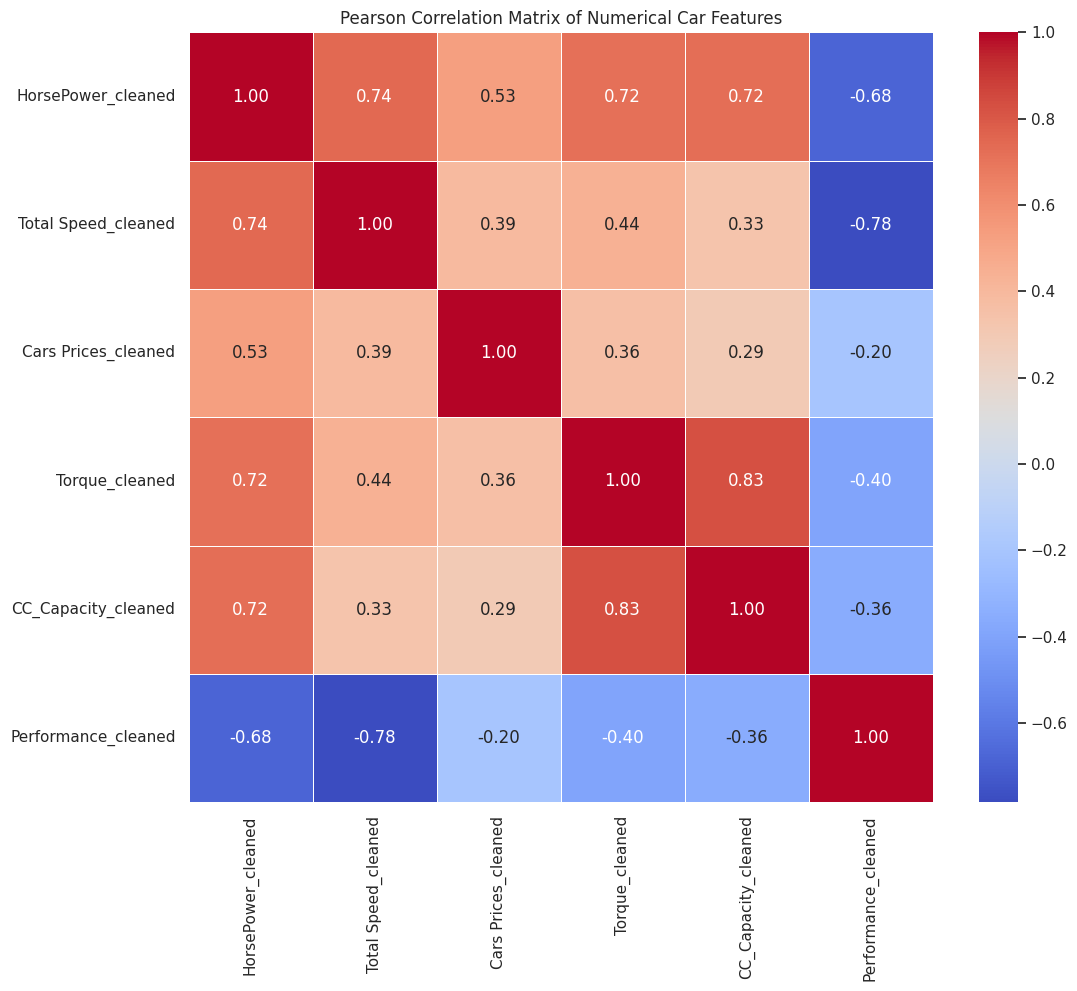

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the list of columns to be included in the final cleaned DataFrame.
# This block is re-added here for robustness in case df_clean definition cell was skipped.
selected_columns = [
    'Company Names',
    'Cars Names',
    'Fuel Types',
    'Seats',
    'HorsePower_cleaned',
    'Total Speed_cleaned',
    'Cars Prices_cleaned',
    'Torque_cleaned',
    'CC_Capacity_cleaned',
    'Battery_Capacity_cleaned',
    'Performance_cleaned',
    'Engine_Battery_Description',
    'Engine_Category'
]
# Create the new DataFrame 'df_clean' with the selected and fully processed columns.
# Ensure df is defined before this. If not, it means prior cells were not run.
df_clean = df[selected_columns].copy()

# Select numerical columns for correlation analysis, excluding 'Battery_Capacity_cleaned' due to high missing values.
numerical_df_clean_corr = df_clean.select_dtypes(include=np.number).drop(columns=['Battery_Capacity_cleaned'], errors='ignore')

print("--- Pearson Correlation Matrix (Linear Relationships) ---")
# Note: Pearson correlation is sensitive to outliers and assumes a linear relationship.
# Given the presence of significant outliers, especially in 'Cars Prices_cleaned',
# interpretations of Pearson coefficients should be made with caution.
# Rank-based correlations (Spearman, Kendall) may offer a more robust view of monotonic relationships.
pearson_correlation_matrix = numerical_df_clean_corr.corr(method='pearson')
display(pearson_correlation_matrix)

# Visualize Pearson correlation
plt.figure(figsize=(12, 10))
sns.heatmap(pearson_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of Numerical Car Features')
plt.show()

#### Spearman and Kendall Rank Correlation (Monotonic Relationships)

While Pearson measures linear relationships, Spearman and Kendall measure monotonic relationships (where variables move in the same or opposite direction, but not necessarily at a constant rate). These are more robust to outliers and can capture non-linear but consistent trends.

--- Spearman Correlation Matrix (Monotonic Relationships) ---


,HorsePower_cleaned,Total Speed_cleaned,Cars Prices_cleaned,Torque_cleaned,CC_Capacity_cleaned,Performance_cleaned
HorsePower_cleaned,1.000000,0.678389,0.914391,0.864486,0.832885,-0.865387
Total Speed_cleaned,0.678389,1.000000,0.660425,0.585226,0.419281,-0.838200
Cars Prices_cleaned,0.914391,0.660425,1.000000,0.858329,0.755240,-0.801458
Torque_cleaned,0.864486,0.585226,0.858329,1.000000,0.781107,-0.718557
CC_Capacity_cleaned,0.832885,0.419281,0.755240,0.781107,1.000000,-0.589041
Performance_cleaned,-0.865387,-0.838200,-0.801458,-0.718557,-0.589041,1.000000


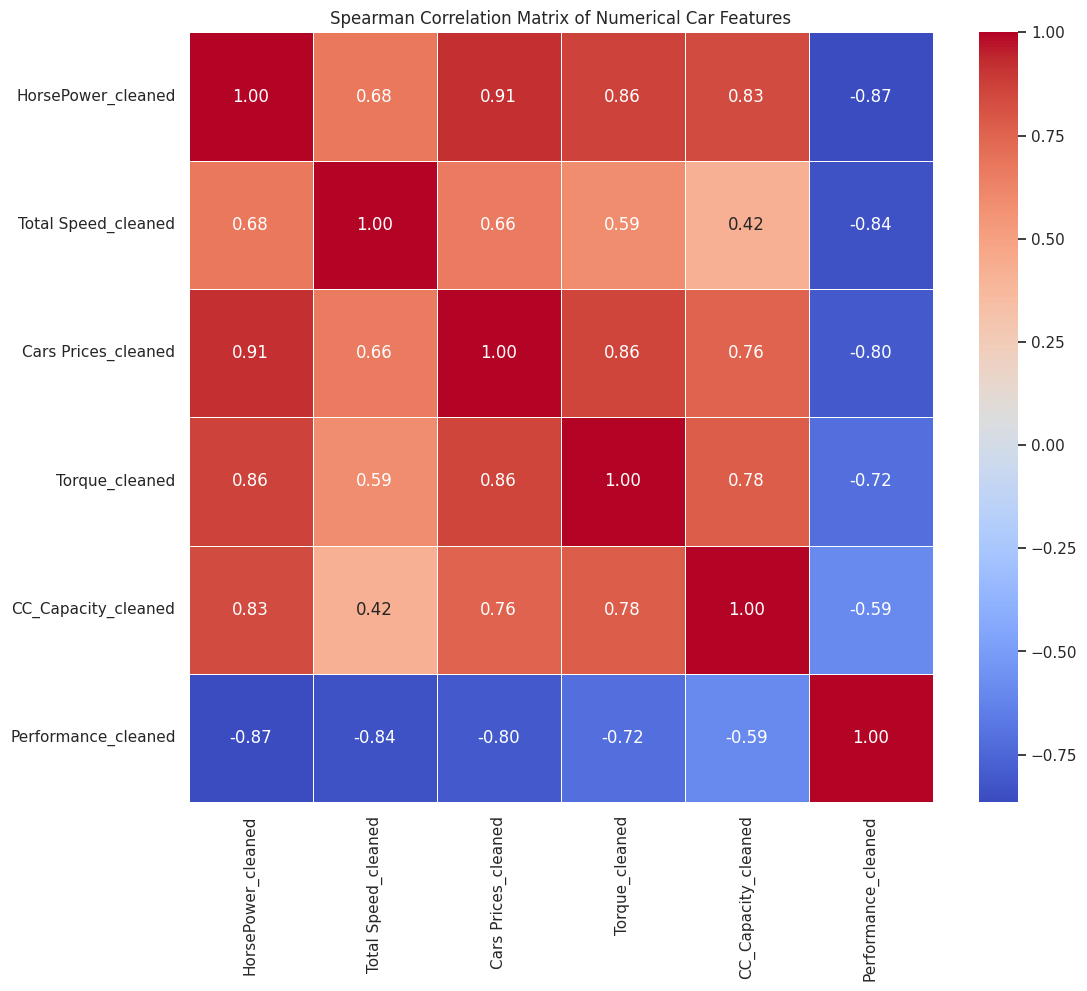


--- Kendall Correlation Matrix (Monotonic Relationships, based on concordance) ---


,HorsePower_cleaned,Total Speed_cleaned,Cars Prices_cleaned,Torque_cleaned,CC_Capacity_cleaned,Performance_cleaned
HorsePower_cleaned,1.000000,0.531021,0.755749,0.731474,0.639294,-0.708521
Total Speed_cleaned,0.531021,1.000000,0.510801,0.452606,0.312696,-0.703193
Cars Prices_cleaned,0.755749,0.510801,1.000000,0.704882,0.556710,-0.632611
Torque_cleaned,0.731474,0.452606,0.704882,1.000000,0.598466,-0.566063
CC_Capacity_cleaned,0.639294,0.312696,0.556710,0.598466,1.000000,-0.423095
Performance_cleaned,-0.708521,-0.703193,-0.632611,-0.566063,-0.423095,1.000000


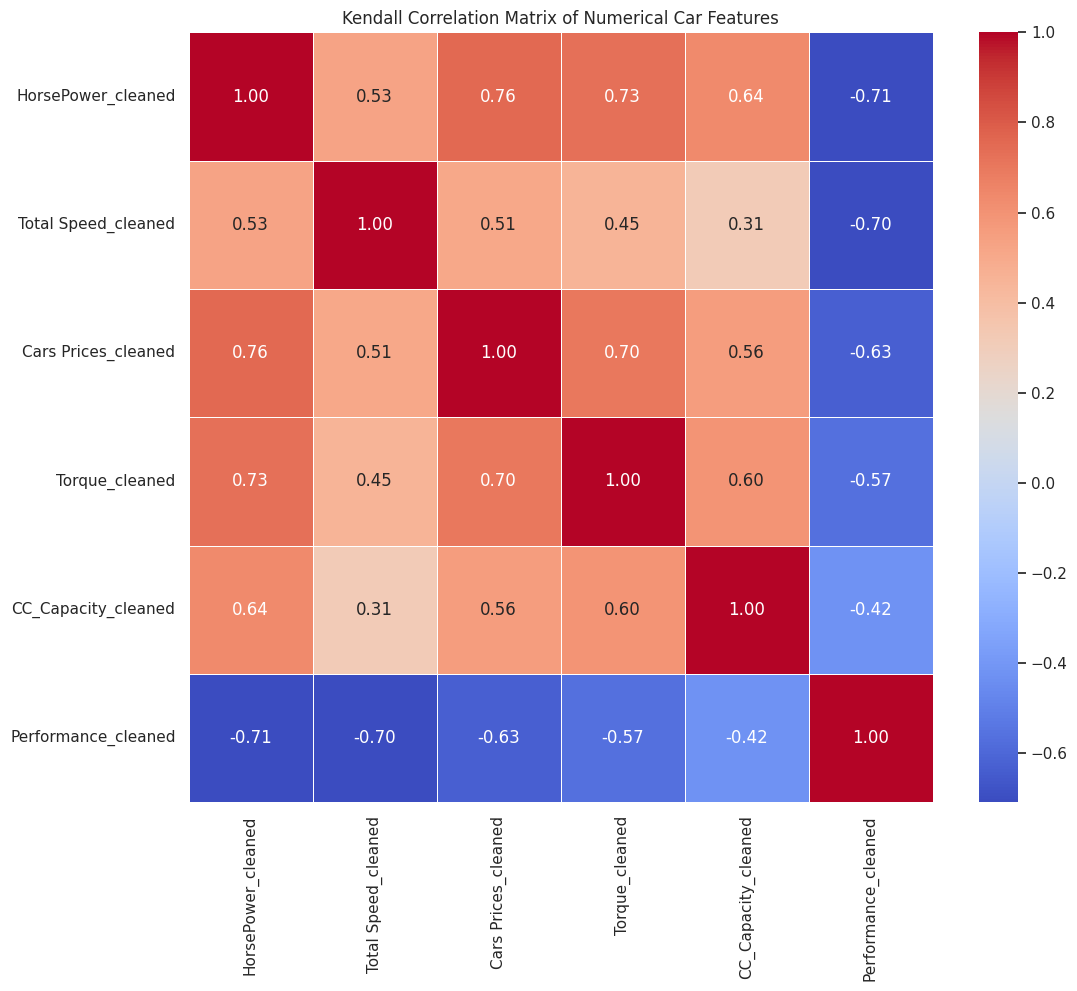

In [ ]:
print("--- Spearman Correlation Matrix (Monotonic Relationships) ---")
spearman_correlation_matrix = numerical_df_clean_corr.corr(method='spearman')
display(spearman_correlation_matrix)

# Visualize Spearman correlation
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Spearman Correlation Matrix of Numerical Car Features')
plt.show()

print("\n--- Kendall Correlation Matrix (Monotonic Relationships, based on concordance) ---")
kendall_correlation_matrix = numerical_df_clean_corr.corr(method='kendall')
display(kendall_correlation_matrix)

# Visualize Kendall correlation
plt.figure(figsize=(12, 10))
sns.heatmap(kendall_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Kendall Correlation Matrix of Numerical Car Features')
plt.show()


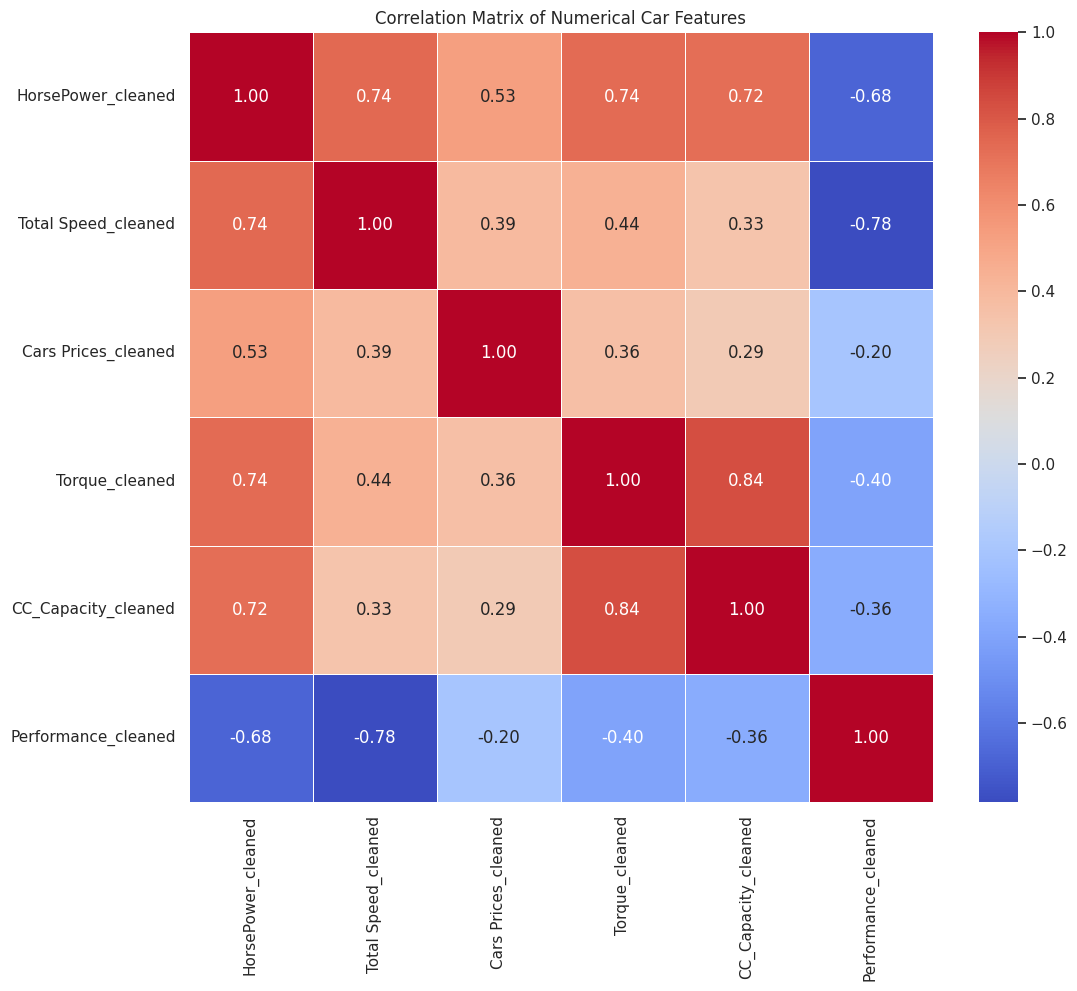

In [ ]:
# Visualize the correlation matrix using a heatmap for easy interpretation.
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Car Features')
plt.show()

### Categorical-Categorical Analysis and Binning

To understand relationships between categorical variables and to create new features for analysis, we'll perform cross-tabulations and bin a numerical variable into categories.


#### Cross-Tabulation (Crosstab)

Cross-tabulations are essential for examining the relationship between two or more categorical variables. They show the frequency distribution of one variable in relation to another, revealing patterns and dependencies.

In [ ]:
import scipy.stats as stats

print("--- Crosstab: Fuel Types vs. Engine Category ---")
crosstab_fuel_engine = pd.crosstab(df_clean['Fuel Types'], df_clean['Engine_Category'])
display(crosstab_fuel_engine)

# Calculate Cramer's V for Fuel Types vs. Engine Category
# Function to calculate Cramer's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cv_fuel_engine = cramers_v(df_clean['Fuel Types'], df_clean['Engine_Category'])
print(f"Cramer's V for Fuel Types vs. Engine Category: {cv_fuel_engine:.3f}")

print("\n--- Crosstab: Seats vs. Engine Category (Normalized by row) ---")
crosstab_seats_engine = pd.crosstab(df_clean['Seats'], df_clean['Engine_Category'], normalize='index') * 100
display(crosstab_seats_engine.round(2))

cv_seats_engine = cramers_v(df_clean['Seats'], df_clean['Engine_Category'])
print(f"Cramer's V for Seats vs. Engine Category: {cv_seats_engine:.3f}")

--- Crosstab: Fuel Types vs. Engine Category ---


Engine_Category,2L,DIESEL,ELECTRIC MOTOR,HYBRID,I3,I4,I6,Other,V12,V6,V8
Fuel Types,,,,,,,,,,,
CNG/Petrol,0,0,0,0,0,0,0,1,0,0,0
Diesel,0,33,0,0,8,40,10,1,0,3,11
Diesel Hybrid,0,0,0,1,0,0,0,0,0,0,0
Diesel/Petrol,0,1,0,0,0,0,0,3,0,0,0
Electric,0,0,92,0,0,0,0,4,0,0,0
Gas / Hybrid,0,0,0,1,0,0,0,0,0,0,0
Hybrid,2,0,22,18,2,17,0,3,2,11,1
Hybrid (Gas + Electric),0,0,0,0,0,1,0,0,0,0,0
Hybrid (Petrol),0,0,4,0,0,0,0,0,0,0,0


Cramer's V for Fuel Types vs. Engine Category: 0.369

--- Crosstab: Seats vs. Engine Category (Normalized by row) ---


Engine_Category,2L,DIESEL,ELECTRIC MOTOR,HYBRID,I3,I4,I6,Other,V12,V6,V8
Seats,,,,,,,,,,,
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00
12,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00
15,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00,0.00,0.00,0.00
2,3.70,2.22,2.96,0.74,0.74,9.63,8.15,28.15,12.59,15.56,15.56
2+2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,20.00,0.00,0.00,80.00
20,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
212,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
215,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
26,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,100.00


Cramer's V for Seats vs. Engine Category: 0.205


#### Binning Numerical Variables

Binning involves grouping a range of numerical values into 'bins' or categories. This can simplify continuous data, make it easier to interpret, and is often used to create new categorical features for modeling or analysis. We'll bin `Cars Prices_cleaned` into price segments.


In [ ]:
# Define price bins and labels
price_bins = [0, 50000, 150000, 500000, df_clean['Cars Prices_cleaned'].max() + 1] # +1 to include max value
price_labels = ['Entry-Level (<$50K)', 'Mid-Range ($50K-$150K)', 'Premium ($150K-$500K)', 'Luxury (>$500K)']

# Create a new binned categorical column
df_clean.loc[:, 'Price_Segment'] = pd.cut(df_clean['Cars Prices_cleaned'], bins=price_bins, labels=price_labels, right=False)

print("--- Distribution of New 'Price_Segment' Category ---")
display(df_clean['Price_Segment'].value_counts())

print("\n--- First 5 rows with new 'Price_Segment' ---")
display(df_clean[['Cars Prices_cleaned', 'Price_Segment']].head())


--- Distribution of New 'Price_Segment' Category ---


,count
Price_Segment,
Entry-Level (<$50K),704
Mid-Range ($50K-$150K),372
Premium ($150K-$500K),105
Luxury (>$500K),32



--- First 5 rows with new 'Price_Segment' ---


,Cars Prices_cleaned,Price_Segment
0,1100000,Luxury (>$500K)
1,460000,Premium ($150K-$500K)
2,12000,Entry-Level (<$50K)
3,161000,Premium ($150K-$500K)
4,253290,Premium ($150K-$500K)


### Visualizing Key Linear Relationships

From the correlation matrix, we've identified several strong linear relationships. To further investigate and visualize these connections, we will use scatter plots with regression lines. These plots help us understand the direction, strength, and nature of the relationships between important car features, such as horsepower, top speed, acceleration performance, and price.

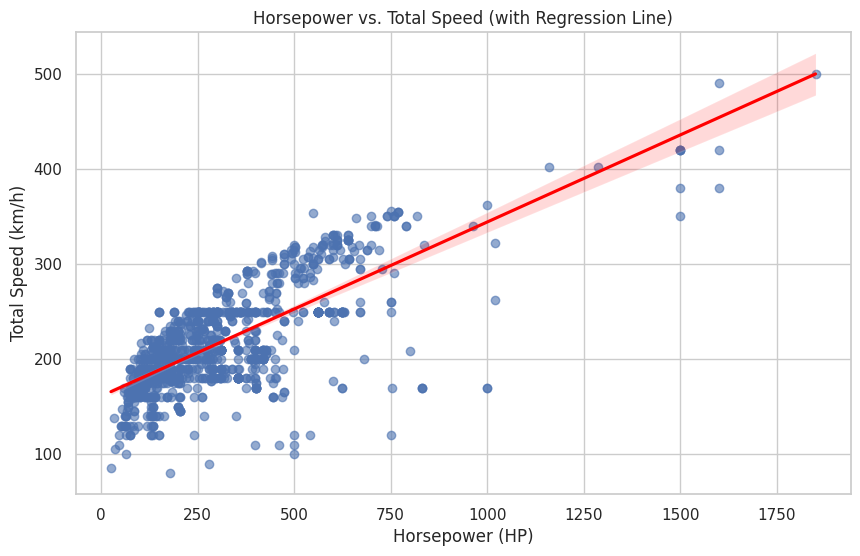

In [ ]:
# Relationship 1: Horsepower vs. Total Speed
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='HorsePower_cleaned', y='Total Speed_cleaned', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Horsepower vs. Total Speed (with Regression Line)')
plt.xlabel('Horsepower (HP)')
plt.ylabel('Total Speed (km/h)')
plt.grid(True)
plt.show()

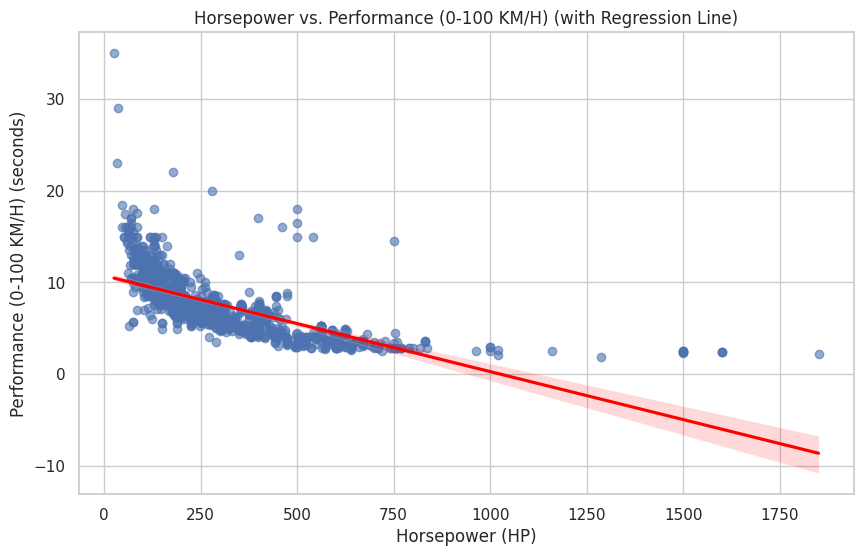

In [ ]:
# Relationship 2: Horsepower vs. Performance (0-100 KM/H)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='HorsePower_cleaned', y='Performance_cleaned', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Horsepower vs. Performance (0-100 KM/H) (with Regression Line)')
plt.xlabel('Horsepower (HP)')
plt.ylabel('Performance (0-100 KM/H) (seconds)')
plt.grid(True)
plt.show()

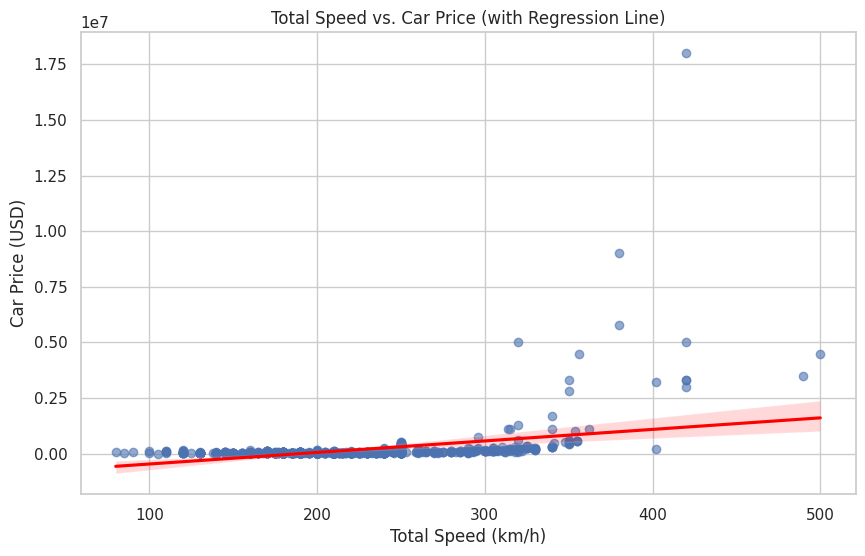

In [ ]:
# Relationship 3: Total Speed vs. Car Price
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='Total Speed_cleaned', y='Cars Prices_cleaned', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Total Speed vs. Car Price (with Regression Line)')
plt.xlabel('Total Speed (km/h)')
plt.ylabel('Car Price (USD)')
plt.grid(True)
plt.show()

### Additional Visualizations for Data Distribution and Relationships

To gain a deeper understanding of the data's characteristics, we'll generate several additional types of plots: Histograms for distribution, Boxplots and Violin plots for spread and potential outliers across categories, Pie Charts for categorical proportions, and a Pairplot for quick insights into multivariate relationships.


#### Histograms: Distribution of Key Numerical Features

Histograms illustrate the underlying frequency distribution of numerical data, helping us understand shape, central tendency, and spread.


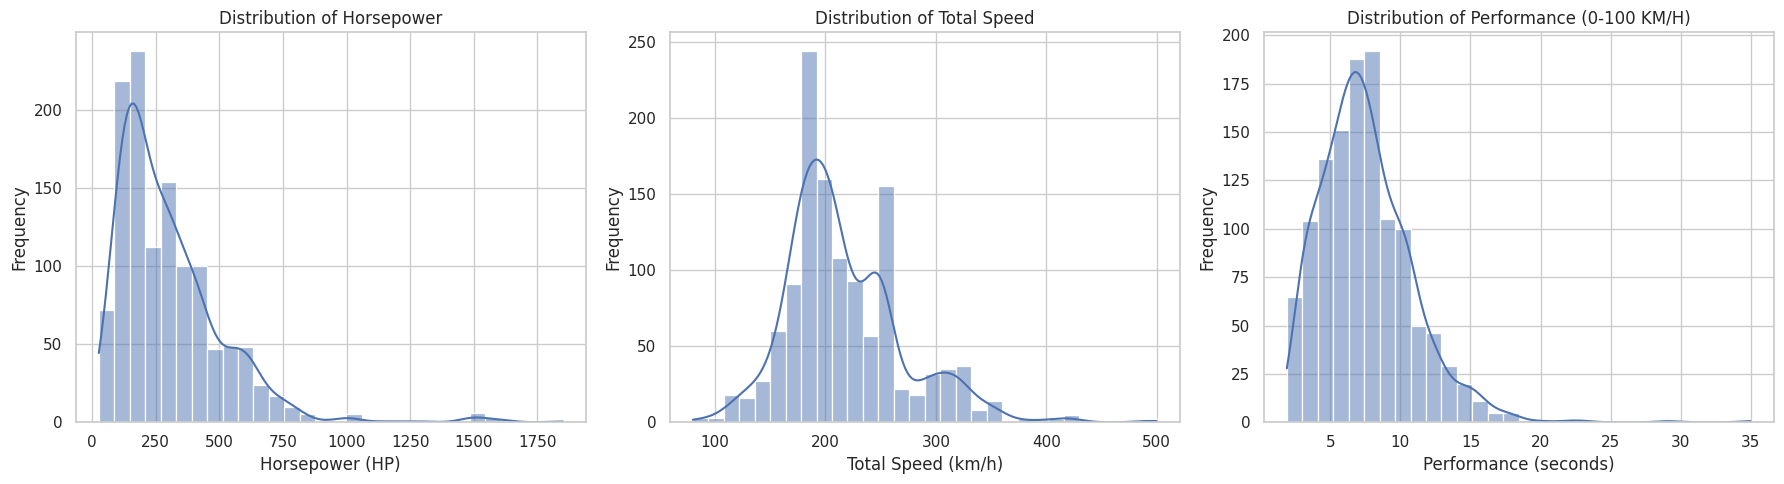

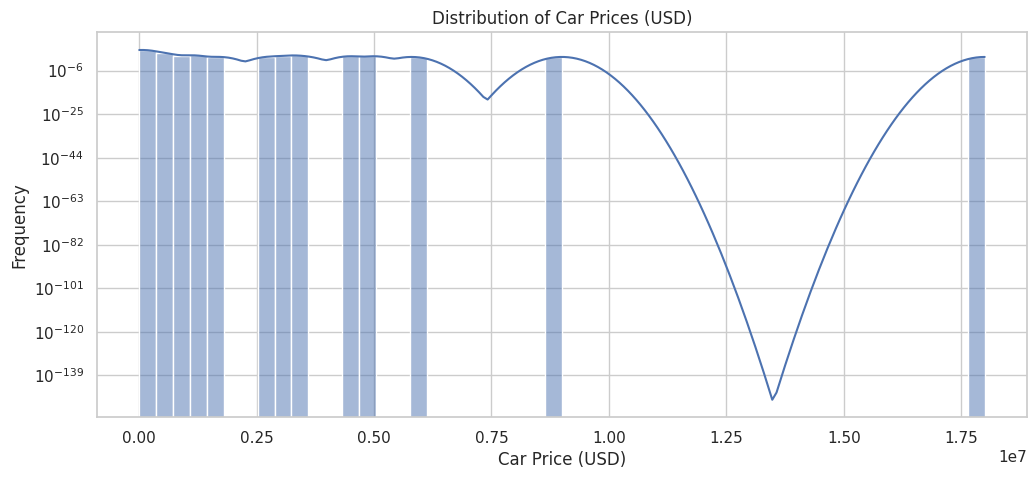

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_clean['HorsePower_cleaned'], kde=True, bins=30)
plt.title('Distribution of Horsepower')
plt.xlabel('Horsepower (HP)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(df_clean['Total Speed_cleaned'], kde=True, bins=30)
plt.title('Distribution of Total Speed')
plt.xlabel('Total Speed (km/h)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(df_clean['Performance_cleaned'], kde=True, bins=30)
plt.title('Distribution of Performance (0-100 KM/H)')
plt.xlabel('Performance (seconds)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(df_clean['Cars Prices_cleaned'], kde=True, bins=50)
plt.title('Distribution of Car Prices (USD)')
plt.xlabel('Car Price (USD)')
plt.ylabel('Frequency')
plt.yscale('log') # Use log scale for y-axis due to high skewness
plt.show()


#### Boxplots and Violin Plots: Performance and Price by Category

Boxplots effectively display the distribution of numerical data and highlight outliers, while violin plots add the dimension of probability density, giving a richer view of data distribution within each category.


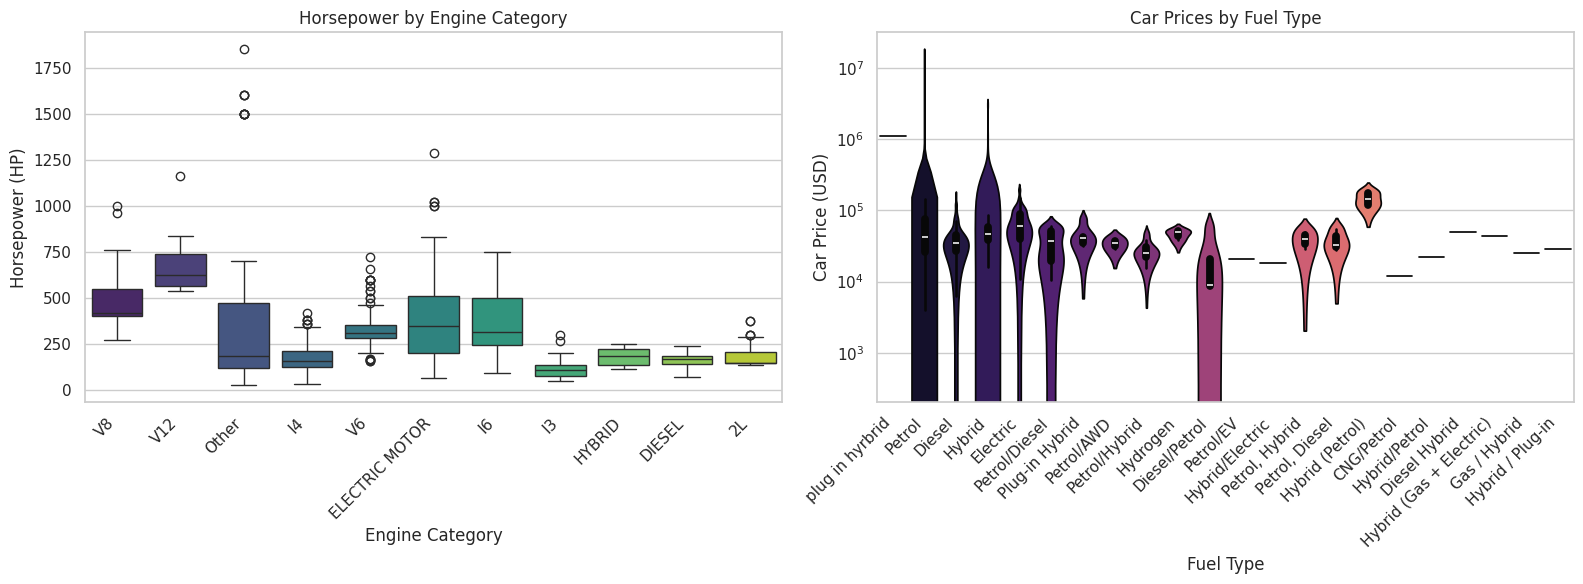

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='Engine_Category', y='HorsePower_cleaned', data=df_clean, hue='Engine_Category', palette='viridis', legend=False)
plt.title('Horsepower by Engine Category')
plt.xlabel('Engine Category')
plt.ylabel('Horsepower (HP)')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.violinplot(x='Fuel Types', y='Cars Prices_cleaned', data=df_clean, hue='Fuel Types', palette='magma', legend=False)
plt.title('Car Prices by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Car Price (USD)')
plt.yscale('log') # Log scale for price due to wide range
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


#### Pie Chart: Proportion of Fuel Types

Pie charts are useful for showing the proportional distribution of a categorical variable.


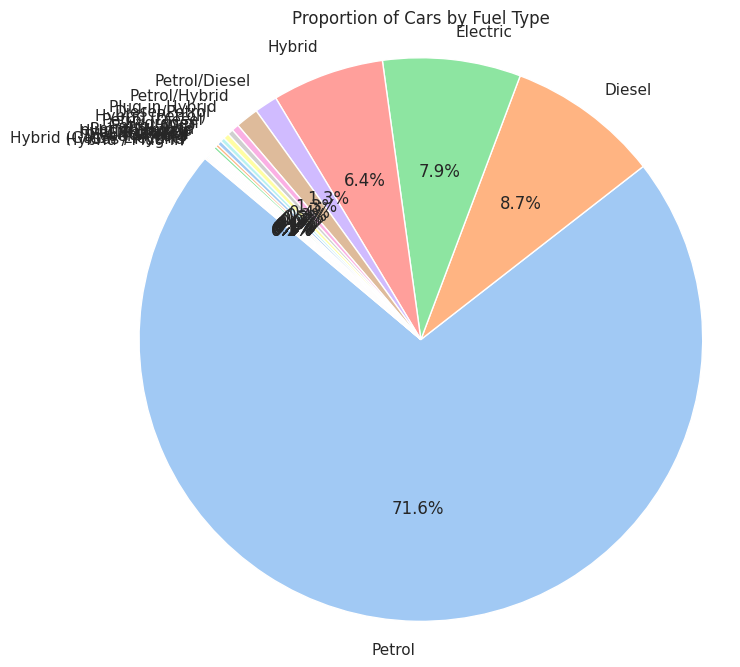

In [ ]:
fuel_type_counts = df_clean['Fuel Types'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(fuel_type_counts, labels=fuel_type_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Cars by Fuel Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


#### Pairplot: Overview of Numerical Relationships

A pairplot (or scatterplot matrix) creates a grid of scatterplots for pairs of variables in a dataset, and histograms for individual variables. It's excellent for quickly visualizing relationships and distributions across multiple numerical features.


--- Generating Pairplot (this may take a moment) ---


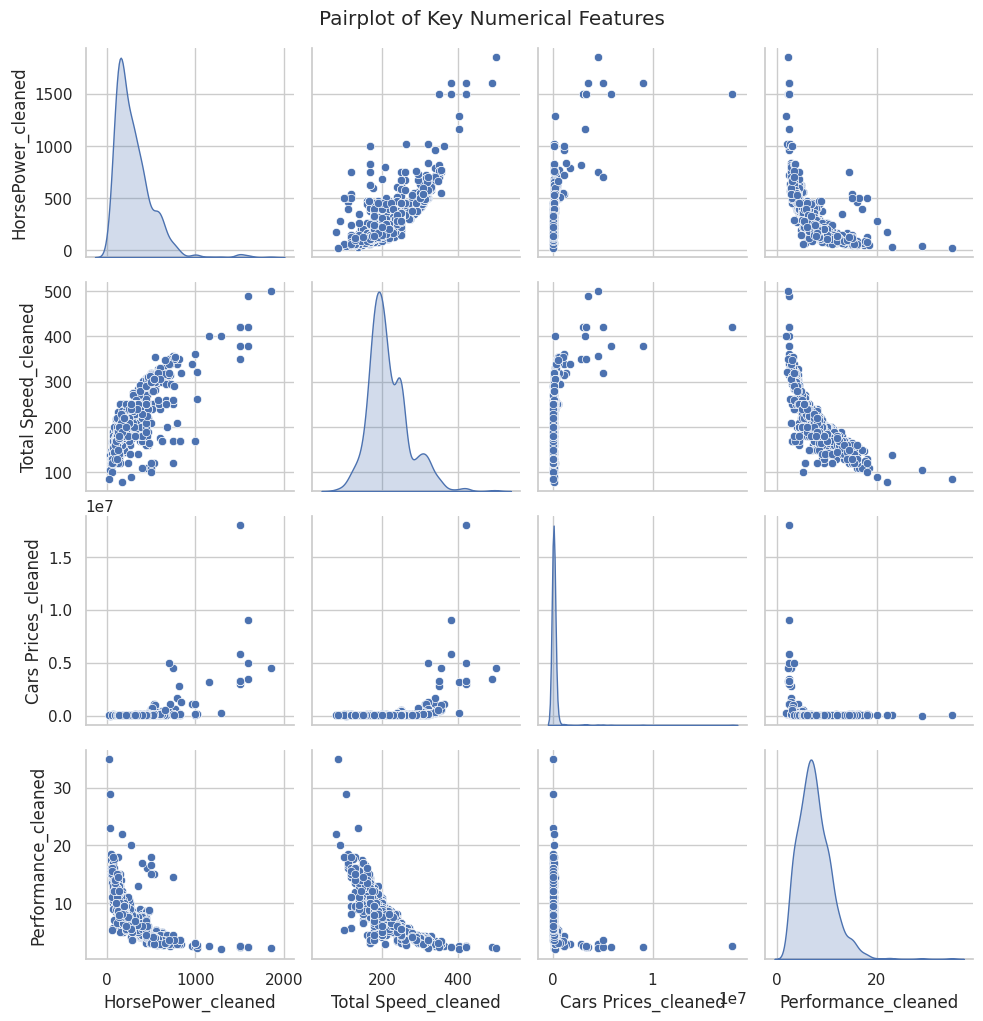

--- Pairplot Generated ---


In [ ]:
numerical_features_for_pairplot = [
    'HorsePower_cleaned',
    'Total Speed_cleaned',
    'Cars Prices_cleaned',
    'Performance_cleaned'
]

# Create a pairplot for a subset of numerical features
# Note: This can be computationally intensive for large datasets or many features.
print("--- Generating Pairplot (this may take a moment) ---")
sns.pairplot(df_clean[numerical_features_for_pairplot].dropna(), diag_kind='kde')
plt.suptitle('Pairplot of Key Numerical Features', y=1.02) # Adjust title position
plt.show()
print("--- Pairplot Generated ---")


In [ ]:
selected_correlations = pd.DataFrame({
    'Relationship': [
        'Horsepower_cleaned vs. Total Speed_cleaned',
        'HorsePower_cleaned vs. Performance_cleaned',
        'Total Speed_cleaned vs. Performance_cleaned',
        'HorsePower_cleaned vs. Cars Prices_cleaned',
        'Total Speed_cleaned vs. Cars Prices_cleaned'
    ],
    'Correlation Coefficient': [
        correlation_matrix.loc['HorsePower_cleaned', 'Total Speed_cleaned'],
        correlation_matrix.loc['HorsePower_cleaned', 'Performance_cleaned'],
        correlation_matrix.loc['Total Speed_cleaned', 'Performance_cleaned'],
        correlation_matrix.loc['HorsePower_cleaned', 'Cars Prices_cleaned'],
        correlation_matrix.loc['Total Speed_cleaned', 'Cars Prices_cleaned']
    ]
})

print("--- Summary of Strong Linear Correlations ---")
display(selected_correlations)

--- Summary of Strong Linear Correlations ---


,Relationship,Correlation Coefficient
0,Horsepower_cleaned vs. Total Speed_cleaned,0.743665
1,HorsePower_cleaned vs. Performance_cleaned,-0.680736
2,Total Speed_cleaned vs. Performance_cleaned,-0.783450
3,HorsePower_cleaned vs. Cars Prices_cleaned,0.531268
4,Total Speed_cleaned vs. Cars Prices_cleaned,0.389579


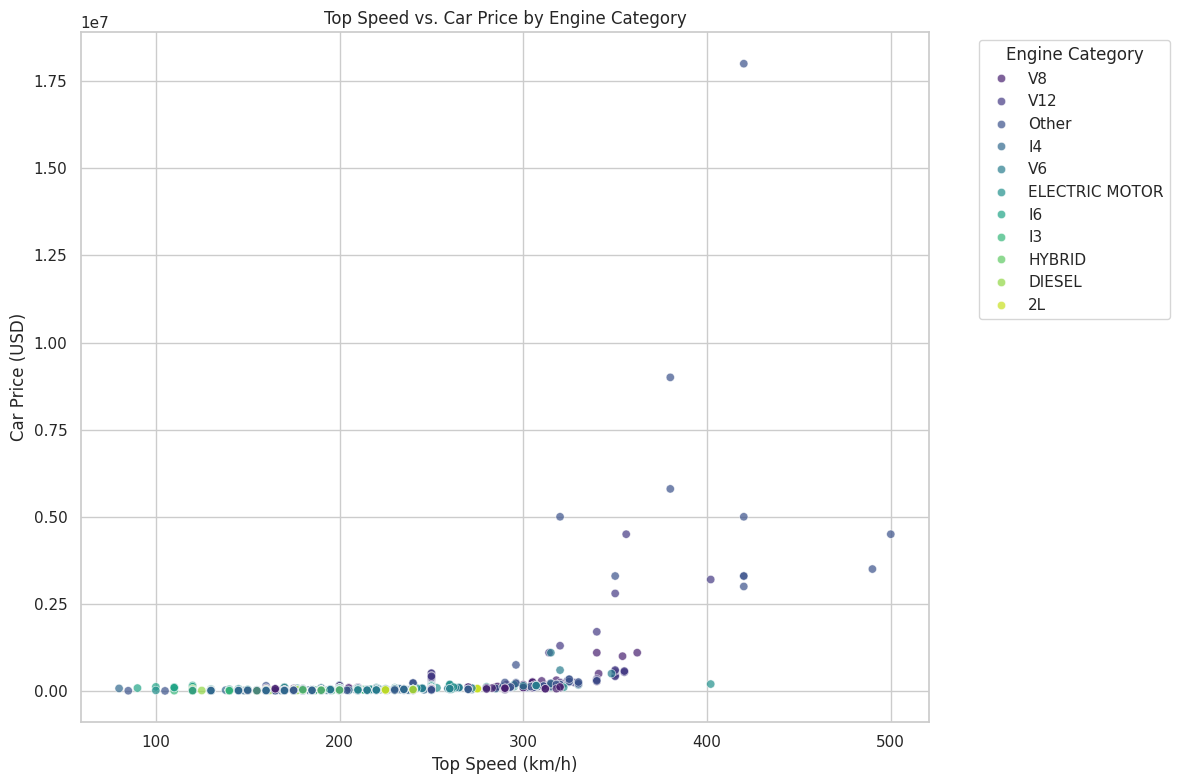

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_clean, x='Total Speed_cleaned', y='Cars Prices_cleaned', hue='Engine_Category', palette='viridis', alpha=0.7)
plt.title('Top Speed vs. Car Price by Engine Category')
plt.xlabel('Top Speed (km/h)')
plt.ylabel('Car Price (USD)')
plt.grid(True)
plt.legend(title='Engine Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Distribution of Engine Categories

Understanding the prevalence of different engine types in the market provides valuable context for product development and market positioning. This bar chart visualizes the frequency of each simplified engine category, allowing us to quickly identify dominant engine types and niche segments in the 2025 car dataset.

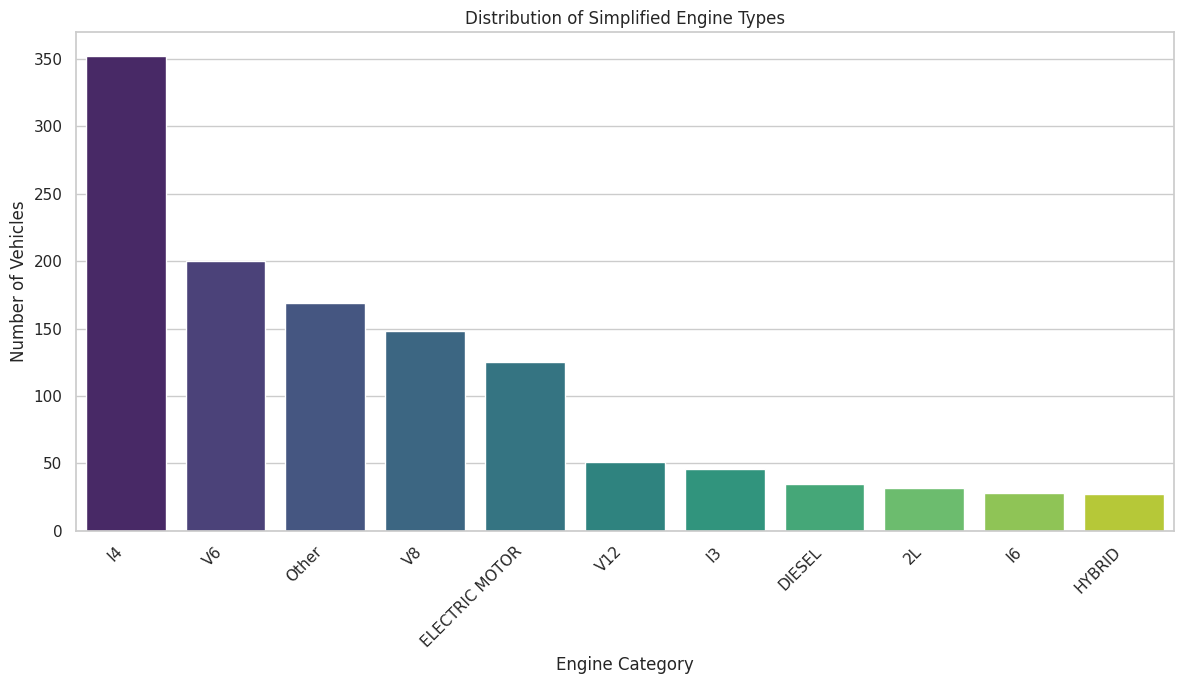

In [ ]:
# Calculate the frequency of the new engine categories.
engine_category_counts = df_clean['Engine_Category'].value_counts()

# Create a bar chart to visualize the distribution.
plt.figure(figsize=(12, 7))
sns.barplot(x=engine_category_counts.index, y=engine_category_counts.values, hue=engine_category_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Simplified Engine Types')
plt.xlabel('Engine Category')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Part 7 - Summary, Conclusions, and Business Implications

This comprehensive exploratory data analysis of the 'Cars Datasets 2025' has provided significant insights into the automotive market for the upcoming year. By cleaning, transforming, and visualizing the data, we've uncovered key trends and relationships that can inform strategic decision-making in the industry.

### Key Findings:

1.  **Performance-Price Correlation with Nuance**: We observed strong correlations between `HorsePower_cleaned`, `Total Speed_cleaned`, and `Cars Prices_cleaned`. **While Pearson correlation suggested linear relationships, due to the identified outliers (e.g., in car prices), the stronger Spearman and Kendall rank correlations (e.g., Spearman 0.91 for horsepower and price) provide a more robust indication of a strong *monotonic* relationship.** This implies that as performance metrics increase, prices generally increase, even if not strictly linearly. **It's crucial to remember that correlation does not imply causation; factors like brand perception (confounding variable, e.g., 'Company Names') often drive both high performance and high prices, rather than performance alone being the sole causal factor for price.** Further analysis within specific manufacturers would be needed to isolate direct causal links.

2.  **Performance and Acceleration**: A strong negative correlation exists between `HorsePower_cleaned` and `Performance_cleaned` (0-100 KM/H). This is expected, as higher horsepower leads to faster acceleration times (lower seconds to reach 100 KM/H). This confirms that the data accurately reflects real-world physics.

3.  **Engine Category Landscape**: The distribution of engine categories highlights the dominance of traditional Internal Combustion Engines (I4, V6, V8) but also shows a significant presence of ELECTRIC MOTORS and HYBRID vehicles. This indicates a diverse market transitioning towards electrification.

4.  **Anomalies and Data Quality**: Our meticulous cleaning process, including the correction of electric vehicle horsepower anomalies and the Nissan Urvan 'cc' misplacement, ensured the reliability of our findings. **Our refined imputation strategy for `Performance_cleaned` (using group-based medians) and explicit identification of MNAR missingness for `Battery_Capacity_cleaned` are examples of advanced data quality measures that prevent biased results and demonstrate a deeper understanding of data characteristics.** Such anomalies, if left unaddressed, could significantly skew statistical results and lead to incorrect conclusions.

### Business Implications:

*   **Market Positioning**: Companies can use the nuanced relationship between performance metrics and price to strategically position their new models. For instance, manufacturers targeting the high-performance luxury segment should emphasize horsepower, top speed, and rapid acceleration, understanding that consumers are willing to pay a premium for these attributes. However, they should also consider the brand's influence as a confounding factor.

*   **Electrification Trend**: The notable presence of electric and hybrid vehicles underscores the ongoing shift in the automotive industry. Manufacturers should continue to invest in R&D for electric powertrains and charging infrastructure. Marketing efforts should highlight the unique performance benefits (e.g., instant torque, quiet operation) and environmental advantages of electric and hybrid models.

*   **Targeted Product Development**: The distribution of engine categories can guide product development. While V8 and V12 engines cater to niche high-performance and luxury markets, the widespread I4 and V6 engines represent the mass-market segment. Understanding the 'Other' category might reveal emerging engine technologies or highly specific regional preferences.

*   **Competitive Analysis**: This analysis provides a baseline for competitive intelligence. By understanding the performance-to-price ratios of various car brands and models, companies can identify gaps in the market, assess their competitive standing, and inform pricing strategies for their 2025 lineup.

*   **Data-Driven Decision Making**: The process demonstrated here emphasizes the importance of data quality. Investing in robust data collection and cleaning processes is crucial for accurate market analysis and informed strategic decisions, preventing misinterpretations from erroneous data points.

### Conclusion:

The 2025 car market is characterized by a strong link between performance and price, alongside a growing embrace of electric and hybrid technologies. By leveraging these insights, stakeholders in the automotive industry can make more informed decisions regarding product development, marketing, and competitive strategy, ensuring they remain agile and relevant in an evolving landscape.